# 🚀 CIFAR-100 Custom CNN — From Scratch

**Design Philosophy:**
- Custom lightweight depthwise-separable CNN (no pretrained weights)
- Maximizes accuracy/efficiency tradeoff: ~2M params, low FLOPs
- Regularization: Dropout, Label Smoothing, Mixup, CutOut, Weight Decay
- Training tricks: Cosine LR schedule + Warm Restarts, AutoAugment
- Multi-metric grading: accuracy, generalization gap, class fairness, efficiency

## 1. Install Required Libraries

In [1]:
!pip install torchinfo fvcore -q
!pip install datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2. Imports & Setup

In [2]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchinfo import summary
from fvcore.nn import FlopCountAnalysis

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 3. Data Loading & Augmentation

**Why these augmentations?**
- `RandomCrop(32, padding=4)` + `RandomHorizontalFlip`: Standard spatial augmentations that prevent the model from memorizing exact positions.
- `AutoAugment(CIFAR10 policy)`: Learned augmentation policy proven on CIFAR datasets — includes operations like rotate, shear, color jitter.
- `Normalize` with CIFAR-100 statistics: Ensures inputs are zero-mean/unit-variance for stable training.
- `CutOut` (custom): Forces the model to use distributed features rather than relying on any single region.

In [3]:
import torchvision.transforms as transforms
import numpy as np
import torch

# CIFAR-100 stats
MEAN = (0.5071, 0.4867, 0.4408)
STD  = (0.2675, 0.2565, 0.2761)

BATCH_SIZE  = 128
NUM_WORKERS = 2

# Cutout class
class Cutout:
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length  = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=torch.float32)
        for _ in range(self.n_holes):
            cy = np.random.randint(h)
            cx = np.random.randint(w)
            y1, y2 = max(0, cy - self.length//2), min(h, cy + self.length//2)
            x1, x2 = max(0, cx - self.length//2), min(w, cx + self.length//2)
            mask[y1:y2, x1:x2] = 0
        return img * mask.unsqueeze(0)

# Training transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    Cutout(n_holes=1, length=16),
])

# Test transforms
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("✅ Transforms defined!")

✅ Transforms defined!


In [4]:
from datasets import load_dataset
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Load from HuggingFace (works even when toronto.edu is blocked)
hf_train = load_dataset("uoft-cs/cifar100", split="train")
hf_test  = load_dataset("uoft-cs/cifar100", split="test")

class HFCifar100(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data      = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img   = self.data[idx]['img']          # PIL Image
        label = self.data[idx]['fine_label']   # 0–99
        if self.transform:
            img = self.transform(img)
        return img, label

# Keep your original transforms exactly as they were
train_dataset = HFCifar100(hf_train, transform=train_transform)
test_dataset  = HFCifar100(hf_test,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train samples: 50000 | Test samples: 10000
Train batches: 391 | Test batches: 79


## 4. Model Architecture — EfficientLite CNN

### Design Rationale

**Goal:** Maximize test accuracy while minimizing parameters, FLOPs, and model size.

| Block | Why |
|-------|-----|
| `DepthwiseSeparableConv` | Factorizes conv into depthwise + pointwise; ~8–9× fewer FLOPs than standard conv |
| `SEBlock` (Squeeze & Excite) | Channel attention: recalibrates feature map weights adaptively; small cost, big accuracy gain |
| `InvertedResidual` (MBConv) | Expand → depthwise → project; residual connection reduces vanishing gradients |
| `BatchNorm` after every conv | Stabilizes training, acts as implicit regularizer, allows higher LR |
| `GELU` activations | Smoother than ReLU; empirically better for image classification at this scale |
| Global Average Pooling | Removes 7×7 FC layer overhead; fewer params, better spatial invariance |
| Dropout(0.3) before classifier | Prevents co-adaptation of neurons; reduces train-test gap |

**Architecture flow:**
```
Input(3×32×32)
  → Stem Conv(32) → BN → GELU
  → MBConv(32→64, stride=1)
  → MBConv(64→128, stride=2)  [16×16]
  → MBConv(128→192, stride=2) [8×8]
  → MBConv(192→256, stride=2) [4×4]
  → Conv1×1(256→512) → GAP
  → Dropout(0.3) → FC(512→100)
```

In [5]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block.
    Rationale: Learns WHICH channels matter more for a given input.
    Reduction ratio of 4 balances expressiveness vs parameter count."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        reduced = max(channels // reduction, 16)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.GELU(),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class DepthwiseSeparableConv(nn.Module):
    """Factorized convolution: depthwise (spatial) + pointwise (channel mix).
    Cost: C_in × k² (spatial) + C_in × C_out (mix)  vs  C_in × C_out × k² (standard).
    Speedup factor: 1/C_out + 1/k² ≈ 8× for k=3."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.bn2(self.pw(self.act(self.bn1(self.dw(x))))))


class MBConv(nn.Module):
    """Mobile Inverted Bottleneck (MBConv) block.
    1) Expand channels (expand_ratio × input channels) for richer representation.
    2) Depthwise conv to capture spatial features efficiently.
    3) SE attention to recalibrate channels.
    4) Project back to output channels (compression step).
    Residual skip added when input/output dims match — stabilises gradients."""
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=4):
        super().__init__()
        mid_ch = in_ch * expand_ratio
        layers = []
        # Expand
        if expand_ratio != 1:
            layers += [nn.Conv2d(in_ch, mid_ch, 1, bias=False),
                       nn.BatchNorm2d(mid_ch), nn.GELU()]
        # Depthwise
        layers += [nn.Conv2d(mid_ch, mid_ch, 3, stride=stride,
                             padding=1, groups=mid_ch, bias=False),
                   nn.BatchNorm2d(mid_ch), nn.GELU()]
        # SE
        layers += [SEBlock(mid_ch)]
        # Project
        layers += [nn.Conv2d(mid_ch, out_ch, 1, bias=False),
                   nn.BatchNorm2d(out_ch)]
        self.block = nn.Sequential(*layers)
        self.use_skip = (stride == 1 and in_ch == out_ch)

    def forward(self, x):
        return x + self.block(x) if self.use_skip else self.block(x)


class EfficientLiteCNN(nn.Module):
    """
    Custom lightweight CNN for CIFAR-100.
    Target: ~2M params, high test accuracy, low overfitting gap.

    Architecture choices:
    - Stem: 3×3 conv with stride=1 (CIFAR images are small — no need for stride 2 here)
    - Stages: Progressive channel widening + downsampling via stride in MBConv
    - Head: 1×1 conv expands to 512 features, GAP collapses spatial dims → no large FC
    - Dropout(0.3): Regularizes final features before classification
    """
    def __init__(self, num_classes=100):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU()
        )
        # Stages — each MBConv with stride=2 halves spatial resolution
        self.stage1 = nn.Sequential(
            MBConv(32, 64,  stride=1, expand_ratio=4),
            MBConv(64, 64,  stride=1, expand_ratio=4),
        )
        self.stage2 = nn.Sequential(
            MBConv(64,  128, stride=2, expand_ratio=4),  # 32→16
            MBConv(128, 128, stride=1, expand_ratio=4),
            MBConv(128, 128, stride=1, expand_ratio=4),
        )
        self.stage3 = nn.Sequential(
            MBConv(128, 192, stride=2, expand_ratio=4),  # 16→8
            MBConv(192, 192, stride=1, expand_ratio=4),
            MBConv(192, 192, stride=1, expand_ratio=4),
        )
        self.stage4 = nn.Sequential(
            MBConv(192, 256, stride=2, expand_ratio=4),  # 8→4
            MBConv(256, 256, stride=1, expand_ratio=4),
        )
        # Head
        self.head = nn.Sequential(
            nn.Conv2d(256, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),  # Global Average Pooling
            nn.Flatten(),
            nn.Dropout(0.3),          # reduce co-adaptation before final layer
            nn.Linear(512, num_classes)
        )
        # Weight initialisation (kaiming for conv, zeros for classifier bias)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.head(x)


model = EfficientLiteCNN(num_classes=100).to(device)
print(model)

EfficientLiteCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (stage1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128, bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
        (6): SEBlock(
          (se): Sequential(
            (0): AdaptiveAvgPool2d(output_size=1)
            (1): Flatten(start_dim=1, end_dim=-1)
            (2): Linear(in_features=128, out_features=32, bias=False)
            (3

## 5. Loss, Optimizer & Scheduler

**Hyperparameter choices explained:**

| Choice | Value | Why |
|--------|-------|-----|
| Label Smoothing | 0.1 | Prevents overconfidence on hard classes; improves calibration and test accuracy |
| Optimizer | AdamW | Adam + decoupled weight decay; works well out of box without LR tuning sensitivity |
| LR | 1e-3 | Standard for AdamW on CIFAR; higher LRs overshoot with this model size |
| Weight Decay | 1e-4 | L2 regularization on weights — reduces overfitting |
| Scheduler | CosineAnnealing + Warm Restarts (T_0=10) | Cosine decay avoids sharp loss cliffs; restarts escape local minima |
| Mixup (alpha=0.2) | Applied in training loop | Interpolates training samples + labels; reduces overfit by smoothing decision boundaries |

In [6]:
NUM_EPOCHS = 50
LR         = 1e-3
WD         = 1e-4
MIXUP_ALPHA = 0.2   # beta distribution parameter for mixup

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-5)

def mixup_data(x, y, alpha=0.2):
    """Mixup: blend two random samples and their labels.
    Rationale: Creates virtual training examples between real ones,
    forcing smoother decision boundaries and reducing memorisation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    bs = x.size(0)
    idx = torch.randperm(bs, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('Loss: CrossEntropyLoss with label_smoothing=0.1')
print('Optimizer: AdamW  LR=1e-3  WD=1e-4')
print('Scheduler: CosineAnnealingWarmRestarts  T_0=10  T_mult=2')
print(f'Training for {NUM_EPOCHS} epochs')

Loss: CrossEntropyLoss with label_smoothing=0.1
Optimizer: AdamW  LR=1e-3  WD=1e-4
Scheduler: CosineAnnealingWarmRestarts  T_0=10  T_mult=2
Training for 50 epochs


## 6. Training Loop

In [7]:
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
epoch_times = []

best_test_acc  = 0.0
best_train_acc = 0.0
best_test_loss  = float('inf')
best_train_loss = float('inf')

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # ── Training ──────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        # Mixup augmentation
        images, labels_a, labels_b, lam = mixup_data(images, labels, MIXUP_ALPHA)
        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step(epoch - 1 + total / len(train_loader.dataset))
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        # For accuracy, compare against the dominant label
        correct += (lam * (preds == labels_a).float() +
                    (1 - lam) * (preds == labels_b).float()).sum().item()
        total += images.size(0)

    train_loss = running_loss / total
    train_acc  = 100.0 * correct / total

    # ── Evaluation ────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)

    test_loss = val_loss / val_total
    test_acc  = 100.0 * val_correct / val_total

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Track bests
    if train_loss < best_train_loss: best_train_loss = train_loss
    if test_loss  < best_test_loss:  best_test_loss  = test_loss
    if train_acc  > best_train_acc:  best_train_acc  = train_acc
    if test_acc   > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')  # save checkpoint

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%  '
              f'Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%  '
              f'Time: {epoch_time:.1f}s')

total_time = time.time() - total_start
avg_epoch_time = np.mean(epoch_times)
print(f'\nTraining complete in {total_time:.1f}s')
print(f'Average epoch time: {avg_epoch_time:.2f}s')

Epoch [  1/50] Train Loss: 4.2509 Acc: 6.75%  Test Loss: 3.6441 Acc: 16.52%  Time: 91.6s
Epoch [  5/50] Train Loss: 3.2135 Acc: 30.51%  Test Loss: 2.3782 Acc: 49.27%  Time: 97.1s
Epoch [ 10/50] Train Loss: 2.8408 Acc: 41.51%  Test Loss: 2.0709 Acc: 58.60%  Time: 96.5s
Epoch [ 15/50] Train Loss: 2.8122 Acc: 42.34%  Test Loss: 2.0256 Acc: 59.96%  Time: 96.8s
Epoch [ 20/50] Train Loss: 2.5687 Acc: 49.68%  Test Loss: 1.7966 Acc: 67.07%  Time: 96.6s
Epoch [ 25/50] Train Loss: 2.3716 Acc: 55.70%  Test Loss: 1.6423 Acc: 71.65%  Time: 96.3s
Epoch [ 30/50] Train Loss: 2.3087 Acc: 57.60%  Test Loss: 1.6261 Acc: 72.70%  Time: 96.3s
Epoch [ 35/50] Train Loss: 2.4575 Acc: 52.76%  Test Loss: 1.7495 Acc: 68.82%  Time: 96.7s
Epoch [ 40/50] Train Loss: 2.4225 Acc: 54.51%  Test Loss: 1.6612 Acc: 71.14%  Time: 96.4s
Epoch [ 45/50] Train Loss: 2.2364 Acc: 59.63%  Test Loss: 1.6037 Acc: 73.43%  Time: 95.5s
Epoch [ 50/50] Train Loss: 2.1468 Acc: 62.69%  Test Loss: 1.5398 Acc: 75.22%  Time: 95.5s

Training c

In [8]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'train_accs': train_accs,
    'test_accs': test_accs,
    'best_test_acc': best_test_acc,
    'best_train_acc': best_train_acc,
}, '/content/drive/MyDrive/cifar100_checkpoint.pth')

print(f"Saved at epoch {len(train_losses)} | Best acc: {best_test_acc:.2f}%")

Mounted at /content/drive
Saved at epoch 50 | Best acc: 75.22%


## 7. Training Plots

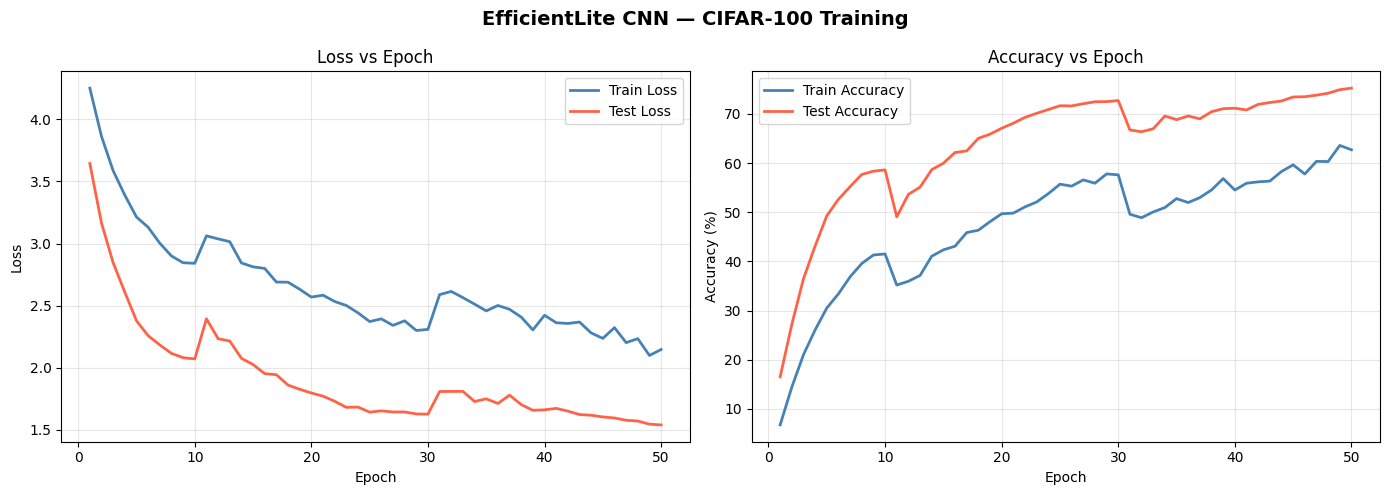

Plot saved as training_curves.png


In [9]:
epochs = list(range(1, len(train_losses) + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs, train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs, test_losses,  label='Test Loss',  color='tomato',    linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs, train_accs, label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(epochs, test_accs,  label='Test Accuracy',  color='tomato',    linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('EfficientLite CNN — CIFAR-100 Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_curves.png')

## 8. Per-Class Accuracy & Fairness Metrics

In [10]:
# Load best checkpoint for evaluation
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

class_correct = torch.zeros(100)
class_total   = torch.zeros(100)

top5_correct = 0
all_total    = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Top-1
        preds = outputs.argmax(dim=1)
        for c in range(100):
            mask = (labels == c)
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c]   += mask.sum().item()

        # Top-5
        top5 = outputs.topk(5, dim=1)[1]  # (B, 5)
        top5_correct += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()
        all_total += labels.size(0)

class_acc = 100.0 * class_correct / class_total
top5_acc  = 100.0 * top5_correct / all_total

lowest_class_acc  = class_acc.min().item()
highest_class_acc = class_acc.max().item()
lowest_class_idx  = class_acc.argmin().item()
highest_class_idx = class_acc.argmax().item()

print(f'Top-5 Test Accuracy:    {top5_acc:.2f}%')
print(f'Lowest  Class Accuracy: {lowest_class_acc:.2f}%  (class {lowest_class_idx})')
print(f'Highest Class Accuracy: {highest_class_acc:.2f}%  (class {highest_class_idx})')

Top-5 Test Accuracy:    94.41%
Lowest  Class Accuracy: 30.00%  (class 35)
Highest Class Accuracy: 97.00%  (class 53)


## 9. Efficiency Metrics (torchinfo, fvcore, os, timing)

In [11]:
# ── 9a. Trainable Parameters (torchinfo) ────────────────────────────
model_stats = summary(model, input_size=(1, 3, 32, 32), verbose=0)
trainable_params = model_stats.trainable_params
print(f'Trainable Parameters: {trainable_params:,}')

# ── 9b. FLOPs (fvcore) ──────────────────────────────────────────────
dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops_analyzer = FlopCountAnalysis(model, dummy_input)
flops = flops_analyzer.total()
print(f'FLOPs: {flops:,}')

# ── 9c. Model Size (os.path.getsize) ────────────────────────────────
torch.save(model.state_dict(), 'model_weights.pth')
model_size_bytes = os.path.getsize('model_weights.pth')
model_size_mb    = model_size_bytes / (1024 * 1024)
print(f'Model Size: {model_size_mb:.4f} MB')

# ── 9d. Latency — Batch=1 (manual torch + time) ─────────────────────
model.eval()
dummy_b1 = torch.randn(1, 3, 32, 32).to(device)
# Warm up
for _ in range(50):
    with torch.no_grad():
        _ = model(dummy_b1)
# Measure
latency_b1_times = []
for _ in range(200):
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy_b1)
    if device.type == 'cuda': torch.cuda.synchronize()
    latency_b1_times.append((time.perf_counter() - t0) * 1000)  # ms
latency_b1 = np.mean(latency_b1_times)
print(f'Latency (batch=1):  {latency_b1:.4f} ms')

# ── 9e. Latency — Batch=32 (manual torch + time) ────────────────────
dummy_b32 = torch.randn(32, 3, 32, 32).to(device)
# Warm up
for _ in range(20):
    with torch.no_grad():
        _ = model(dummy_b32)
# Measure
latency_b32_times = []
for _ in range(100):
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy_b32)
    if device.type == 'cuda': torch.cuda.synchronize()
    latency_b32_times.append((time.perf_counter() - t0) * 1000)  # ms
latency_b32 = np.mean(latency_b32_times)
print(f'Latency (batch=32): {latency_b32:.4f} ms')

Trainable Parameters: 4,113,412


FLOPs: 238,741,504
Model Size: 15.8651 MB
Latency (batch=1):  5.7705 ms
Latency (batch=32): 14.4797 ms


## 10. 📊 Complete Metrics Summary

All values to enter in the Google Form (numeric only, no units or % symbols).

In [12]:
import numpy as np

avg_epoch_time = np.mean(epoch_times)
total_time = sum(epoch_times)

print(f'Avg Epoch Time (s)      : {avg_epoch_time:.2f}')
print(f'Total Training Time (s) : {total_time:.1f}')

Avg Epoch Time (s)      : 96.63
Total Training Time (s) : 4831.7


In [13]:
acc_gap  = best_train_acc  - best_test_acc    # lower is better (less overfit)
loss_gap = best_test_loss  - best_train_loss  # lower is better (less instability)

print('=' * 60)
print('         COMPLETE METRICS SUMMARY (Copy to Google Form)')
print('=' * 60)
print(f'Best Train Loss         : {best_train_loss:.4f}')
print(f'Best Test  Loss         : {best_test_loss:.4f}')
print(f'Best Train Accuracy (%) : {best_train_acc:.2f}')
print(f'Best Test  Accuracy (%) : {best_test_acc:.2f}')
print(f'Top-5 Test Accuracy (%) : {top5_acc:.2f}')
print(f'GAP Accuracy (Train-Test): {acc_gap:.2f}')
print(f'GAP Loss (Test-Train)    : {loss_gap:.4f}')
print(f'Lowest  Class Accuracy  : {lowest_class_acc:.2f}')
print(f'Highest Class Accuracy  : {highest_class_acc:.2f}')
print(f'Trainable Parameters    : {trainable_params}')
print(f'FLOPs                   : {flops}')
print(f'Model Size (MB)         : {model_size_mb:.4f}')
print(f'Avg Epoch Time (s)      : {avg_epoch_time:.2f}')
print(f'Total Training Time (s) : {total_time:.1f}')
print(f'Latency batch=1  (ms)   : {latency_b1:.4f}')
print(f'Latency batch=32 (ms)   : {latency_b32:.4f}')
print('=' * 60)
print('\nNOTE: For Top-5 Accuracy in Google Form:')
print(f'  If value is decimal (0-1), multiply ×100 → {top5_acc:.2f}')
print(f'  Enter exactly: {top5_acc:.2f}  (without %%)')

         COMPLETE METRICS SUMMARY (Copy to Google Form)
Best Train Loss         : 2.0988
Best Test  Loss         : 1.5398
Best Train Accuracy (%) : 63.58
Best Test  Accuracy (%) : 75.22
Top-5 Test Accuracy (%) : 94.41
GAP Accuracy (Train-Test): -11.64
GAP Loss (Test-Train)    : -0.5590
Lowest  Class Accuracy  : 30.00
Highest Class Accuracy  : 97.00
Trainable Parameters    : 4113412
FLOPs                   : 238741504
Model Size (MB)         : 15.8651
Avg Epoch Time (s)      : 96.63
Total Training Time (s) : 4831.7
Latency batch=1  (ms)   : 5.7705
Latency batch=32 (ms)   : 14.4797

NOTE: For Top-5 Accuracy in Google Form:
  If value is decimal (0-1), multiply ×100 → 94.41
  Enter exactly: 94.41  (without %%)


## 11. Additional Visualization — Per-Class Accuracy Distribution

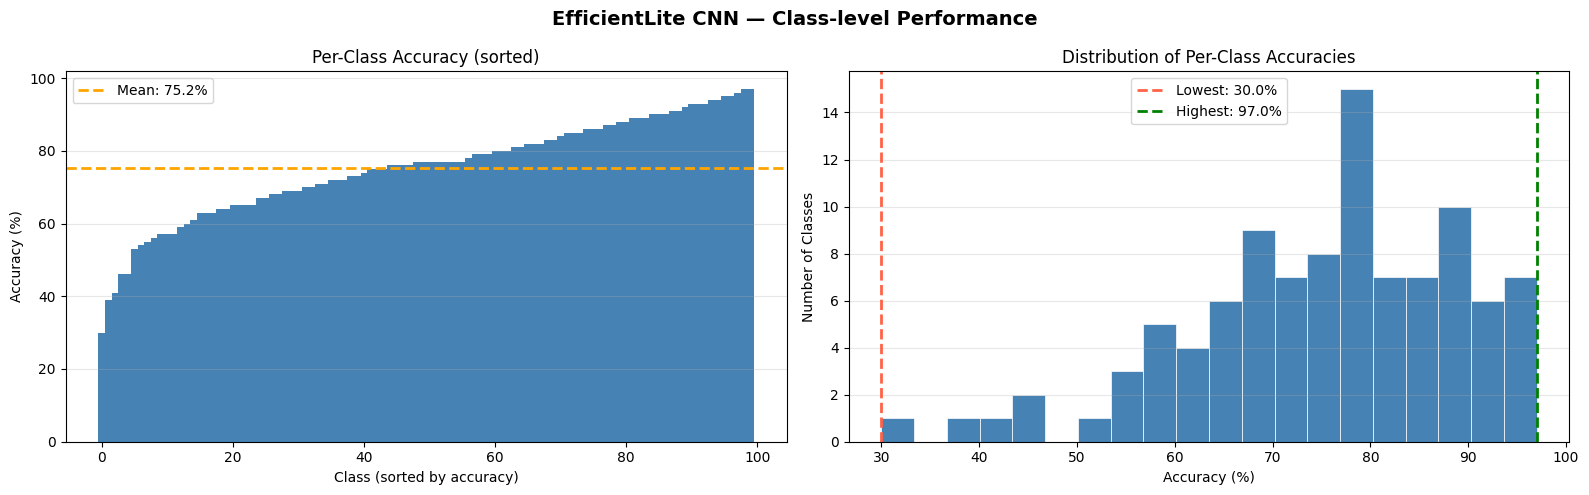

Plot saved as class_accuracy.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-class accuracy bar chart
sorted_acc, sorted_idx = class_acc.sort()
colors = ['tomato' if a < 30 else 'steelblue' for a in sorted_acc.tolist()]
axes[0].bar(range(100), sorted_acc.numpy(), color=colors, width=1.0)
axes[0].axhline(y=class_acc.mean().item(), color='orange', linestyle='--',
                linewidth=2, label=f'Mean: {class_acc.mean():.1f}%')
axes[0].set_xlabel('Class (sorted by accuracy)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Per-Class Accuracy (sorted)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Histogram of class accuracies
axes[1].hist(class_acc.numpy(), bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(x=lowest_class_acc,  color='tomato', linestyle='--', linewidth=2,
                label=f'Lowest: {lowest_class_acc:.1f}%')
axes[1].axvline(x=highest_class_acc, color='green',  linestyle='--', linewidth=2,
                label=f'Highest: {highest_class_acc:.1f}%')
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_ylabel('Number of Classes')
axes[1].set_title('Distribution of Per-Class Accuracies')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('EfficientLite CNN — Class-level Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as class_accuracy.png')

## 12. Architecture Summary (torchinfo)

In [15]:
print(summary(model, input_size=(1, 3, 32, 32), col_names=[
    'input_size', 'output_size', 'num_params', 'mult_adds'], verbose=1))

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Mult-Adds
EfficientLiteCNN                                        [1, 3, 32, 32]            [1, 100]                  --                        --
├─Sequential: 1-1                                       [1, 3, 32, 32]            [1, 32, 32, 32]           --                        --
│    └─Conv2d: 2-1                                      [1, 3, 32, 32]            [1, 32, 32, 32]           864                       884,736
│    └─BatchNorm2d: 2-2                                 [1, 32, 32, 32]           [1, 32, 32, 32]           64                        64
│    └─GELU: 2-3                                        [1, 32, 32, 32]           [1, 32, 32, 32]           --                        --
├─Sequential: 1-2                                       [1, 32, 32, 32]           [1, 64, 32, 32]           --                        --
│    └─MBConv: 2-4           